# **AI-Powered OTT Customer Churn & Revenue Intelligence Platform**


📊 Data Analytics — Python + SQL

📈 Business Intelligence — Power BI

🤖 ML Churn Prediction — Scikit-learn + XGBoost

🔍 Explainable AI — SHAP

👥 Customer Segmentation — K-Means

💰 Revenue Risk Analysis

🧠 AI Business Analyst — LLM

🌐 Interactive App — Streamlit



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("imported libaries successfully")

imported libaries successfully


In [2]:
df= pd.read_csv("/content/Ott_Customer.csv")
print("dataset loaded successfully")

dataset loaded successfully


In [3]:
df.head()

,Customer_ID,Age,Gender,Region,Account_Creation_Date,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,Favorite_Genre,Devices_Registered,Login_Frequency_Per_Week,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Churn_Status,Churn_Reason
0,CUST_1001,24,Female,North America,2022-01-23,Standard,13.61,PayPal,Yes,Annual,18.6,Comedy,2,9,20,0,1,13,Active,Not Churned
1,CUST_1002,46,Female,Middle East & Africa,2023-09-24,Standard,13.80,PayPal,Yes,Annual,9.9,Comedy,5,11,9,0,2,10,Active,Not Churned
2,CUST_1003,29,Female,Europe,2022-09-03,Premium,20.09,Carrier Billing,Yes,Annual,9.0,Anime,4,5,10,2,0,24,Active,Not Churned
3,CUST_1004,51,Male,North America,2023-10-22,Standard,13.77,Credit Card,No,Monthly,3.2,Sci-Fi,1,7,0,1,1,10,Active,Not Churned
4,CUST_1005,21,Male,Middle East & Africa,2021-05-01,Basic,7.89,PayPal,No,Monthly,17.3,Comedy,4,14,11,1,1,4,Active,Not Churned


In [4]:
df.shape

(5000, 20)

In [5]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Region', 'Account_Creation_Date',
       'Subscription_Plan', 'Monthly_Charges', 'Payment_Method',
       'Auto_Renewal', 'Contract_Length', 'Average_Watch_Hours_Per_Week',
       'Favorite_Genre', 'Devices_Registered', 'Login_Frequency_Per_Week',
       'Download_For_Offline_Count', 'Customer_Support_Calls',
       'Streaming_Quality_Issues', 'Days_Since_Last_Login', 'Churn_Status',
       'Churn_Reason'],
      dtype='object')

In [6]:
print("rows",df.shape[0])
print("columns",df.shape[1])

rows 5000
columns 20


In [7]:
print("duplicated rows", df.duplicated().sum())

duplicated rows 0


In [8]:
print("missing values", df.isnull().sum())

missing values Customer_ID                     0
Age                             0
Gender                          0
Region                          0
Account_Creation_Date           0
Subscription_Plan               0
Monthly_Charges                 0
Payment_Method                  0
Auto_Renewal                    0
Contract_Length                 0
Average_Watch_Hours_Per_Week    0
Favorite_Genre                  0
Devices_Registered              0
Login_Frequency_Per_Week        0
Download_For_Offline_Count      0
Customer_Support_Calls          0
Streaming_Quality_Issues        0
Days_Since_Last_Login           0
Churn_Status                    0
Churn_Reason                    0
dtype: int64


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,34.073800,9.538561,18.00,27.00,34.00,41.0000,68.0
Monthly_Charges,5000.0,13.126206,4.500153,6.93,8.16,13.84,14.4925,21.4
Average_Watch_Hours_Per_Week,5000.0,9.796020,5.349322,0.50,5.80,8.70,12.6000,40.0
Devices_Registered,5000.0,3.269000,1.476304,1.00,2.00,3.00,4.0000,7.0
Login_Frequency_Per_Week,5000.0,6.473600,3.219593,1.00,4.00,6.00,8.0000,23.0
Download_For_Offline_Count,5000.0,7.445600,4.212005,0.00,4.00,7.00,10.0000,27.0
Customer_Support_Calls,5000.0,1.016400,1.005750,0.00,0.00,1.00,2.0000,6.0
Streaming_Quality_Issues,5000.0,1.111000,1.051903,0.00,0.00,1.00,2.0000,6.0
Days_Since_Last_Login,5000.0,20.509800,8.939479,0.00,15.00,21.00,27.0000,55.0


In [10]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Customer_ID =====
Customer_ID
CUST_6000    1
CUST_1001    1
CUST_1002    1
CUST_1003    1
CUST_1004    1
            ..
CUST_1013    1
CUST_1012    1
CUST_1011    1
CUST_1010    1
CUST_1009    1
Name: count, Length: 5000, dtype: int64

===== Gender =====
Gender
Male      2427
Female    2362
Other      211
Name: count, dtype: int64

===== Region =====
Region
Asia Pacific            1307
North America           1226
Europe                  1086
Middle East & Africa     704
Latin America            677
Name: count, dtype: int64

===== Account_Creation_Date =====
Account_Creation_Date
2023-10-13    11
2022-03-20     9
2025-11-16     9
2024-10-22     9
2025-12-10     9
              ..
2021-08-29     1
2025-01-01     1
2021-07-07     1
2022-09-22     1
2025-07-23     1
Name: count, Length: 1671, dtype: int64

===== Subscription_Plan =====
Subscription_Plan
Standard    2111
Basic       1804
Premium     1085
Name: count, dtype: int64

===== Payment_Method =====
Payment_Method
Credit Ca

In [11]:
churn_rate = (
    (df["Churn_Status"] == "Churned").sum()
    / len(df)
) * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 19.16%


In [12]:
df["Churn_Flag"] = (
    df["Churn_Status"] == "Churned"
).astype(int)
print(df["Churn_Flag"])

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    1
4998    0
4999    0
Name: Churn_Flag, Length: 5000, dtype: int64


In [13]:
df["Churn_Status"].value_counts()

,count
Churn_Status,
Active,4042
Churned,958


In [14]:
churn_counts = df["Churn_Status"].value_counts()

print(churn_counts)

Churn_Status
Active     4042
Churned     958
Name: count, dtype: int64


In [15]:
churn_percentage = (
    df["Churn_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn_Status
Active     80.84
Churned    19.16
Name: proportion, dtype: float64


In [16]:
churn_summary = pd.DataFrame({
    "Customer_Count": churn_counts,
    "Percentage": churn_percentage
})

churn_summary

,Customer_Count,Percentage
Churn_Status,,
Active,4042,80.84
Churned,958,19.16


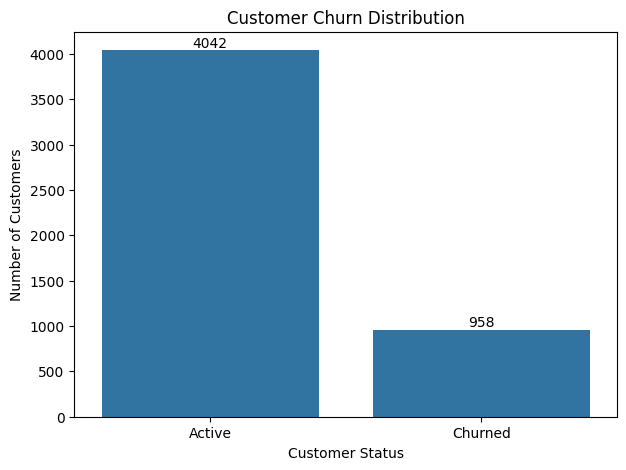

In [17]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn_Status"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

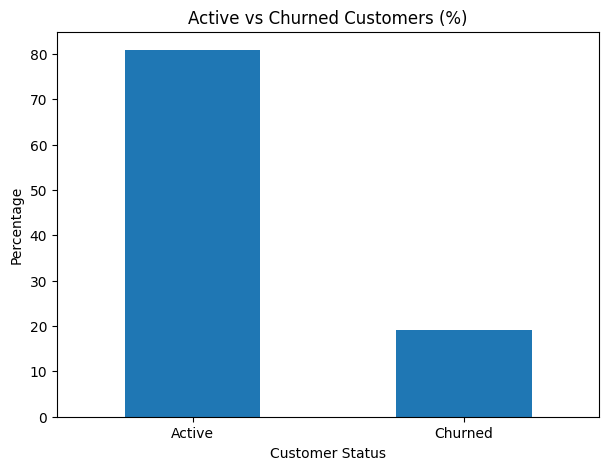

In [18]:
plt.figure(figsize=(7, 5))

churn_percentage.plot(
    kind="bar"
)

plt.title("Active vs Churned Customers (%)")
plt.xlabel("Customer Status")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

# Business Insight: Out of 5,000 customers, 958 are churned, resulting in an overall churn rate of 19.16%. This establishes the baseline retention level for subsequent analysis. The next step is to investigate which customer characteristics and behaviors are associated with higher churn.

In [19]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)
print(df["Age_Group"].head(5))

0    18-25
1    46-55
2    26-35
3    46-55
4    18-25
Name: Age_Group, dtype: category
Categories (5, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56+']


In [20]:
age_churn = (
    df.groupby("Age_Group", observed=True)["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
)

age_churn

,Churn_Flag
Age_Group,
18-25,17.23
26-35,20.32
36-45,19.54
46-55,17.83
56+,18.75


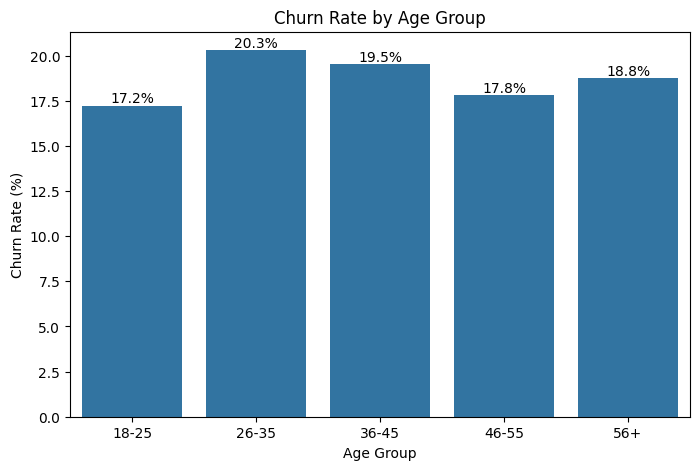

In [21]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [22]:
gender_churn = (
    df.groupby("Gender")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
)

gender_churn

,Churn_Flag
Gender,
Female,19.56
Male,18.75
Other,19.43


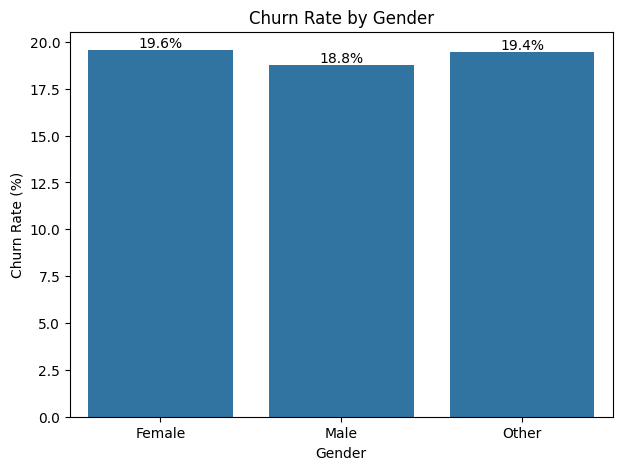

In [23]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [24]:
df["Region"].value_counts()

,count
Region,
Asia Pacific,1307
North America,1226
Europe,1086
Middle East & Africa,704
Latin America,677


In [25]:
region_churn = (
    df.groupby("Region")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

region_churn

,Churn_Flag
Region,
North America,20.23
Europe,19.80
Latin America,19.50
Asia Pacific,18.44
Middle East & Africa,17.33


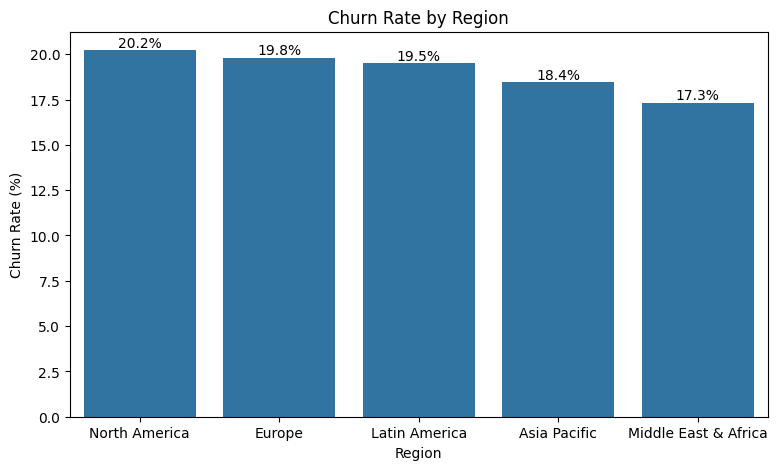

In [26]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=region_churn.index,
    y=region_churn.values
)

plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.xticks(rotation=0)
plt.show()

In [27]:
demographic_summary = pd.DataFrame({
    "Age Churn Rate (%)": age_churn,
    "Gender Churn Rate (%)": gender_churn,
    "Region Churn Rate (%)": region_churn
})

demographic_summary

,Age Churn Rate (%),Gender Churn Rate (%),Region Churn Rate (%)
18-25,17.23,NaN,NaN
26-35,20.32,NaN,NaN
36-45,19.54,NaN,NaN
46-55,17.83,NaN,NaN
56+,18.75,NaN,NaN
Asia Pacific,NaN,NaN,18.44
Europe,NaN,NaN,19.80
Female,NaN,19.56,NaN
Latin America,NaN,NaN,19.50
Male,NaN,18.75,NaN


In [28]:
plan_analysis = (
    df.groupby("Subscription_Plan")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn_Flag", "sum"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

plan_analysis["Churn_Rate"] = (
    plan_analysis["Churn_Rate"] * 100
).round(2)

plan_analysis

,Customers,Churned,Churn_Rate
Subscription_Plan,,,
Basic,1804,305,16.91
Premium,1085,250,23.04
Standard,2111,403,19.09


# Premium subscribers show the highest observed churn rate at 23.04%, compared with the overall churn rate of 19.16%. Basic subscribers have the lowest observed churn rate at 16.91%, while Standard subscribers are approximately aligned with the overall baseline. Further analysis of contract length, auto-renewal, pricing, and engagement is required to understand the factors associated with these differences.

In [29]:
df["Contract_Length"].value_counts()

,count
Contract_Length,
Monthly,3389
Annual,1611


In [30]:
contract_churn = (
    df.groupby("Contract_Length")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

contract_churn

,Churn_Flag
Contract_Length,
Monthly,21.04
Annual,15.21


In [31]:
contract_analysis = (
    df.groupby("Contract_Length")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn_Flag", "sum"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

contract_analysis["Churn_Rate"] = (
    contract_analysis["Churn_Rate"] * 100
).round(2)

contract_analysis

,Customers,Churned,Churn_Rate
Contract_Length,,,
Annual,1611,245,15.21
Monthly,3389,713,21.04


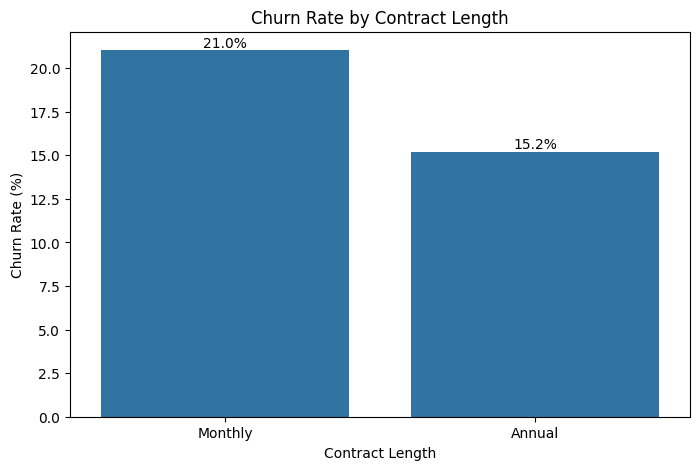

In [32]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

# Monthly-contract customers show an observed churn rate of 21.04%, compared with 15.21% among annual-contract customers. The monthly segment is also substantially larger, accounting for 3,389 customers. This indicates that contract length is an important retention segment to investigate further, although the analysis does not establish that contract length itself causes churn.

In [33]:
df["Auto_Renewal"].value_counts()

,count
Auto_Renewal,
Yes,3750
No,1250


In [34]:
auto_renewal_churn = (
    df.groupby("Auto_Renewal")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

auto_renewal_churn

,Churn_Flag
Auto_Renewal,
No,23.52
Yes,17.71


In [35]:
auto_renewal_analysis = (
    df.groupby("Auto_Renewal")
    .agg(
        Customers=("Customer_ID", "count"),
        Churned=("Churn_Flag", "sum"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

auto_renewal_analysis["Churn_Rate"] = (
    auto_renewal_analysis["Churn_Rate"] * 100
).round(2)

auto_renewal_analysis

,Customers,Churned,Churn_Rate
Auto_Renewal,,,
No,1250,294,23.52
Yes,3750,664,17.71


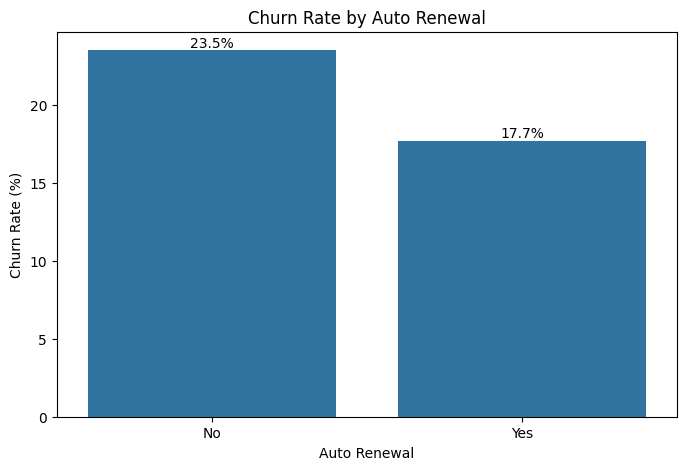

In [36]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=auto_renewal_churn.index,
    y=auto_renewal_churn.values
)

plt.title("Churn Rate by Auto Renewal")
plt.xlabel("Auto Renewal")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

# Customers without auto-renewal have a higher observed churn rate (23.52%) compared with customers with auto-renewal enabled (17.71%), indicating that renewal behavior may be associated with customer retention.

# **CONCLUSION**

Python analysis established an overall customer churn rate of 19.16% across 5,000 customers. Demographic and subscription-level analysis identified differences in observed churn rates across age groups, regions, subscription plans, contract lengths, and auto-renewal status. Monthly-contract customers recorded a 21.04% churn rate compared with 15.21% for annual customers, while customers without auto-renewal recorded 23.52% compared with 17.71% for customers with auto-renewal. These relationships are descriptive and do not establish causation. The next phase will use SQL to reproduce and extend the analysis with business-focused segmentation and aggregation.

# **🤖 ML Churn Prediction — Scikit-learn + XGBoost**

In [37]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [38]:
# Load dataset
df = pd.read_csv("/content/Ott_Customer.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5000, 20)


,Customer_ID,Age,Gender,Region,Account_Creation_Date,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,Favorite_Genre,Devices_Registered,Login_Frequency_Per_Week,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Churn_Status,Churn_Reason
0,CUST_1001,24,Female,North America,2022-01-23,Standard,13.61,PayPal,Yes,Annual,18.6,Comedy,2,9,20,0,1,13,Active,Not Churned
1,CUST_1002,46,Female,Middle East & Africa,2023-09-24,Standard,13.80,PayPal,Yes,Annual,9.9,Comedy,5,11,9,0,2,10,Active,Not Churned
2,CUST_1003,29,Female,Europe,2022-09-03,Premium,20.09,Carrier Billing,Yes,Annual,9.0,Anime,4,5,10,2,0,24,Active,Not Churned
3,CUST_1004,51,Male,North America,2023-10-22,Standard,13.77,Credit Card,No,Monthly,3.2,Sci-Fi,1,7,0,1,1,10,Active,Not Churned
4,CUST_1005,21,Male,Middle East & Africa,2021-05-01,Basic,7.89,PayPal,No,Monthly,17.3,Comedy,4,14,11,1,1,4,Active,Not Churned


In [39]:
# Check target variable
print(df["Churn_Status"].value_counts())

print("\nChurn Percentage:")
print(df["Churn_Status"].value_counts(normalize=True) * 100)

Churn_Status
Active     4042
Churned     958
Name: count, dtype: int64

Churn Percentage:
Churn_Status
Active     80.84
Churned    19.16
Name: proportion, dtype: float64


In [40]:
df["Churn_Flag"] = df["Churn_Status"].map({
    "Active": 0,
    "Churned": 1
})

print(df[["Churn_Status", "Churn_Flag"]].head())

print("\nTarget distribution:")
print(df["Churn_Flag"].value_counts())

  Churn_Status  Churn_Flag
0       Active           0
1       Active           0
2       Active           0
3       Active           0
4       Active           0

Target distribution:
Churn_Flag
0    4042
1     958
Name: count, dtype: int64


In [41]:
# Columns to remove
drop_columns = [
    "Customer_ID",
    "Churn_Status",
    "Churn_Reason"
]

X = df.drop(columns=drop_columns + ["Churn_Flag"])
y = df["Churn_Flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 17)
Target shape: (5000,)


In [42]:
print("Numerical Columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical Columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical Columns:
['Age', 'Monthly_Charges', 'Average_Watch_Hours_Per_Week', 'Devices_Registered', 'Login_Frequency_Per_Week', 'Download_For_Offline_Count', 'Customer_Support_Calls', 'Streaming_Quality_Issues', 'Days_Since_Last_Login']

Categorical Columns:
['Gender', 'Region', 'Account_Creation_Date', 'Subscription_Plan', 'Payment_Method', 'Auto_Renewal', 'Contract_Length', 'Favorite_Genre']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training data: (4000, 17)
Testing data: (1000, 17)

Training target distribution:
Churn_Flag
0    80.85
1    19.15
Name: proportion, dtype: float64

Testing target distribution:
Churn_Flag
0    80.8
1    19.2
Name: proportion, dtype: float64


In [44]:
# ==========================================
# STEP 7.1 — Date Feature Engineering
# ==========================================

X = X.copy()

# Convert date to datetime
X["Account_Creation_Date"] = pd.to_datetime(
    X["Account_Creation_Date"]
)

# Extract useful date features
X["Account_Creation_Year"] = X["Account_Creation_Date"].dt.year
X["Account_Creation_Month"] = X["Account_Creation_Date"].dt.month
X["Account_Creation_Day"] = X["Account_Creation_Date"].dt.day

# Remove original date column
X = X.drop(columns=["Account_Creation_Date"])

print("New feature shape:", X.shape)

X.head()

New feature shape: (5000, 19)


,Age,Gender,Region,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,Favorite_Genre,Devices_Registered,Login_Frequency_Per_Week,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Account_Creation_Year,Account_Creation_Month,Account_Creation_Day
0,24,Female,North America,Standard,13.61,PayPal,Yes,Annual,18.6,Comedy,2,9,20,0,1,13,2022,1,23
1,46,Female,Middle East & Africa,Standard,13.80,PayPal,Yes,Annual,9.9,Comedy,5,11,9,0,2,10,2023,9,24
2,29,Female,Europe,Premium,20.09,Carrier Billing,Yes,Annual,9.0,Anime,4,5,10,2,0,24,2022,9,3
3,51,Male,North America,Standard,13.77,Credit Card,No,Monthly,3.2,Sci-Fi,1,7,0,1,1,10,2023,10,22
4,21,Male,Middle East & Africa,Basic,7.89,PayPal,No,Monthly,17.3,Comedy,4,14,11,1,1,4,2021,5,1


In [45]:
# ==========================================
# STEP 7.2 — Identify Feature Types
# ==========================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Monthly_Charges', 'Average_Watch_Hours_Per_Week', 'Devices_Registered', 'Login_Frequency_Per_Week', 'Download_For_Offline_Count', 'Customer_Support_Calls', 'Streaming_Quality_Issues', 'Days_Since_Last_Login']

Categorical Features:
['Gender', 'Region', 'Subscription_Plan', 'Payment_Method', 'Auto_Renewal', 'Contract_Length', 'Favorite_Genre']


In [46]:
# ==========================================
# STEP 7.3 — Preprocessing Pipeline
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [47]:
# ==========================================
# STEP 7.4 — Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 19)
X_test : (1000, 19)
y_train: (4000,)
y_test : (1000,)


In [48]:
# ==========================================
# STEP 7.5 — Test Preprocessing
# ==========================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (4000, 37)
Processed testing shape : (1000, 37)


In [49]:
# ==========================================
# STEP 7.6 — ML Pipeline
# ==========================================

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [50]:
# ==========================================
# STEP 8.1 — Train Logistic Regression
# ==========================================

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [51]:
# ==========================================
# STEP 8.2 — Predictions
# ==========================================

y_pred = logistic_pipeline.predict(X_test)

print("Predictions generated!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [52]:
# ==========================================
# STEP 8.3 — Churn Probability
# ==========================================

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 20 churn probabilities:")
print(y_prob[:20])

First 20 churn probabilities:
[0.13963744 0.37655327 0.03524699 0.10197723 0.34208851 0.24787489
 0.10167104 0.09299774 0.29429982 0.11695152 0.08227745 0.36099884
 0.03499487 0.31321392 0.15361362 0.48827426 0.30239629 0.24356301
 0.21083294 0.4152732 ]


In [53]:
# ==========================================
# STEP 8.4 — Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))


Accuracy: 0.809


In [54]:
# ==========================================
# STEP 8.5 — Precision
# ==========================================

precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", round(precision, 4))

Precision: 0.5217


In [55]:
# ==========================================
# STEP 8.6 — Recall
# ==========================================

recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", round(recall, 4))

Recall: 0.0625


In [56]:
# ==========================================
# STEP 8.7 — F1 Score
# ==========================================

f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", round(f1, 4))

F1 Score: 0.1116


In [57]:
# ==========================================
# STEP 8.8 — ROC-AUC
# ==========================================

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.7506


In [58]:
# ==========================================
# STEP 8.9 — Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Active", "Churned"]
    )
)

              precision    recall  f1-score   support

      Active       0.82      0.99      0.89       808
     Churned       0.52      0.06      0.11       192

    accuracy                           0.81      1000
   macro avg       0.67      0.52      0.50      1000
weighted avg       0.76      0.81      0.74      1000



In [59]:
# ==========================================
# STEP 8.10 — Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[797  11]
 [180  12]]


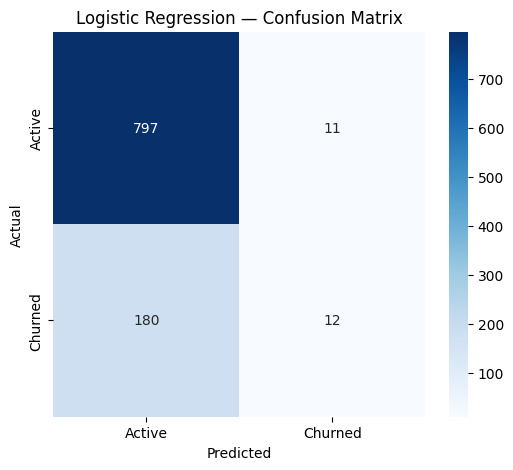

In [60]:
# ==========================================
# STEP 8.11 — Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")

plt.show()

In [61]:
# ==========================================
# STEP 8.12 — Model Results
# ==========================================

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1_Score": f1,
    "ROC_AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.809,
 'Precision': 0.5217391304347826,
 'Recall': 0.0625,
 'F1_Score': 0.11162790697674418,
 'ROC_AUC': np.float64(0.7505607982673267)}

In [62]:
results_df = pd.DataFrame([logistic_results])

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.809,0.521739,0.0625,0.111628,0.750561


In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
# ==========================================
# STEP 9.2 — Random Forest Pipeline
# ==========================================

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [65]:
# ==========================================
# STEP 9.3 — Train Random Forest
# ==========================================

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [66]:
# ==========================================
# STEP 9.4 — Random Forest Predictions
# ==========================================

rf_pred = random_forest_pipeline.predict(X_test)

print("Random Forest predictions generated!")
print("First 20 predictions:")
print(rf_pred[:20])

Random Forest predictions generated!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [67]:
# ==========================================
# STEP 9.5 — Churn Probabilities
# ==========================================

rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("First 20 churn probabilities:")
print(rf_prob[:20])

First 20 churn probabilities:
[0.12  0.365 0.045 0.1   0.155 0.255 0.14  0.14  0.31  0.075 0.125 0.325
 0.03  0.435 0.135 0.38  0.31  0.215 0.2   0.3  ]


In [68]:
# ==========================================
# STEP 9.6 — Accuracy
# ==========================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.811


In [69]:
# ==========================================
# STEP 9.7 — Precision
# ==========================================

rf_precision = precision_score(
    y_test,
    rf_pred
)

print("Random Forest Precision:", round(rf_precision, 4))

Random Forest Precision: 0.7143


In [70]:
# ==========================================
# STEP 9.8 — Recall
# ==========================================

rf_recall = recall_score(
    y_test,
    rf_pred
)

print("Random Forest Recall:", round(rf_recall, 4))

Random Forest Recall: 0.026


In [71]:
# ==========================================
# STEP 9.9 — F1 Score
# ==========================================

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Random Forest F1 Score:", round(rf_f1, 4))

Random Forest F1 Score: 0.0503


In [72]:
# ==========================================
# STEP 9.10 — ROC-AUC
# ==========================================

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))

Random Forest ROC-AUC: 0.7026


In [73]:
# ==========================================
# STEP 9.11 — Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Active", "Churned"]
    )
)

              precision    recall  f1-score   support

      Active       0.81      1.00      0.90       808
     Churned       0.71      0.03      0.05       192

    accuracy                           0.81      1000
   macro avg       0.76      0.51      0.47      1000
weighted avg       0.79      0.81      0.73      1000



In [74]:
# ==========================================
# STEP 9.12 — Confusion Matrix
# ==========================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[806   2]
 [187   5]]


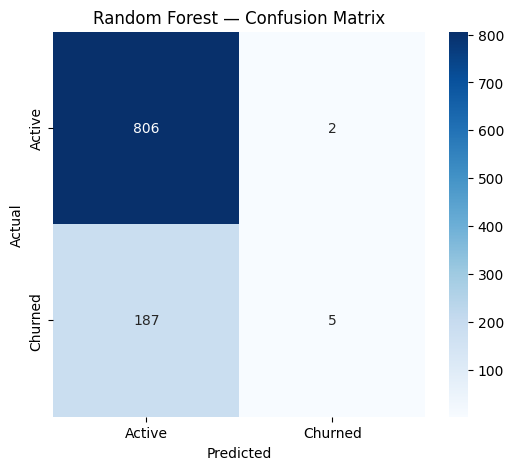

In [75]:
# ==========================================
# STEP 9.13 — Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")

plt.show()

In [76]:
# ==========================================
# STEP 9.14 — Random Forest Results
# ==========================================

rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1_Score": rf_f1,
    "ROC_AUC": rf_roc_auc
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.811,
 'Precision': 0.7142857142857143,
 'Recall': 0.026041666666666668,
 'F1_Score': 0.05025125628140704,
 'ROC_AUC': np.float64(0.7026318842821783)}

In [77]:
# ==========================================
# STEP 9.15 — Compare Current Models
# ==========================================

results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.809,0.521739,0.062500,0.111628,0.750561
1,Random Forest,0.811,0.714286,0.026042,0.050251,0.702632


In [78]:
# ==========================================
# STEP 10.1 — Install XGBoost
# ==========================================

!pip install -q xgboost

In [79]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [80]:
# ==========================================
# STEP 10.2 — XGBoost Pipeline
# ==========================================

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully!")

XGBoost pipeline created successfully!


In [81]:
# ==========================================
# STEP 10.3 — Train XGBoost
# ==========================================

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [82]:
# ==========================================
# STEP 10.4 — XGBoost Predictions
# ==========================================

xgb_pred = xgb_pipeline.predict(X_test)

print("XGBoost predictions generated!")
print("First 20 predictions:")
print(xgb_pred[:20])

XGBoost predictions generated!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [83]:
# ==========================================
# STEP 10.5 — Churn Probabilities
# ==========================================

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("First 20 churn probabilities:")
print(xgb_prob[:20])

First 20 churn probabilities:
[0.15185052 0.313774   0.05285044 0.06985008 0.1205021  0.2983371
 0.08733653 0.12913667 0.1868788  0.06369484 0.08203395 0.31659865
 0.00609164 0.47050452 0.13691358 0.5060145  0.34220213 0.22023341
 0.18560839 0.26860785]


In [84]:
# ==========================================
# STEP 10.6 — Accuracy
# ==========================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))

XGBoost Accuracy: 0.804


In [85]:
# ==========================================
# STEP 10.7 — Precision
# ==========================================

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

print("XGBoost Precision:", round(xgb_precision, 4))

XGBoost Precision: 0.4444


In [86]:
# ==========================================
# STEP 10.8 — Recall
# ==========================================

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

print("XGBoost Recall:", round(xgb_recall, 4))

XGBoost Recall: 0.0833


In [87]:
# ==========================================
# STEP 10.9 — F1 Score
# ==========================================

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

print("XGBoost F1 Score:", round(xgb_f1, 4))

XGBoost F1 Score: 0.1404


In [88]:
# ==========================================
# STEP 10.10 — ROC-AUC
# ==========================================

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("XGBoost ROC-AUC:", round(xgb_roc_auc, 4))

XGBoost ROC-AUC: 0.7017


In [89]:
# ==========================================
# STEP 10.11 — Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Active", "Churned"]
    )
)

              precision    recall  f1-score   support

      Active       0.82      0.98      0.89       808
     Churned       0.44      0.08      0.14       192

    accuracy                           0.80      1000
   macro avg       0.63      0.53      0.51      1000
weighted avg       0.75      0.80      0.75      1000



In [90]:
# ==========================================
# STEP 10.12 — Confusion Matrix
# ==========================================

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("XGBoost Confusion Matrix:")
print(xgb_cm)

XGBoost Confusion Matrix:
[[788  20]
 [176  16]]


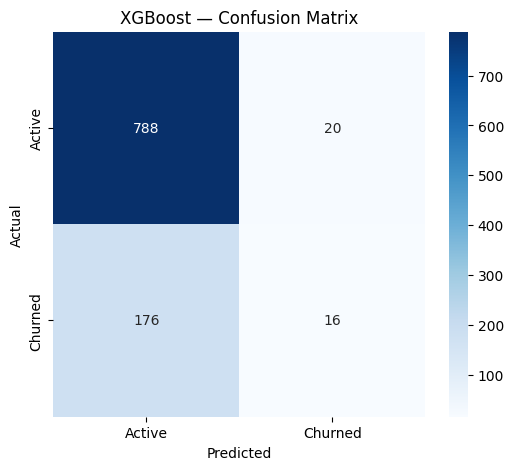

In [91]:
# ==========================================
# STEP 10.13 — XGBoost Confusion Matrix
# ==========================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost — Confusion Matrix")

plt.show()

In [92]:
# ==========================================
# STEP 10.14 — XGBoost Results
# ==========================================

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1_Score": xgb_f1,
    "ROC_AUC": xgb_roc_auc
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.804,
 'Precision': 0.4444444444444444,
 'Recall': 0.08333333333333333,
 'F1_Score': 0.14035087719298245,
 'ROC_AUC': np.float64(0.7017004434818482)}

In [93]:
# ==========================================
# STEP 10.15 — Model Comparison
# ==========================================

results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.809,0.521739,0.062500,0.111628,0.750561
1,Random Forest,0.811,0.714286,0.026042,0.050251,0.702632
2,XGBoost,0.804,0.444444,0.083333,0.140351,0.701700


In [94]:
results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.809,0.5217,0.0625,0.1116,0.7506
1,Random Forest,0.811,0.7143,0.0260,0.0503,0.7026
2,XGBoost,0.804,0.4444,0.0833,0.1404,0.7017


In [95]:
# ==========================================
# STEP 11.1 — Model Comparison
# ==========================================

results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.809,0.5217,0.0625,0.1116,0.7506
1,Random Forest,0.811,0.7143,0.0260,0.0503,0.7026
2,XGBoost,0.804,0.4444,0.0833,0.1404,0.7017


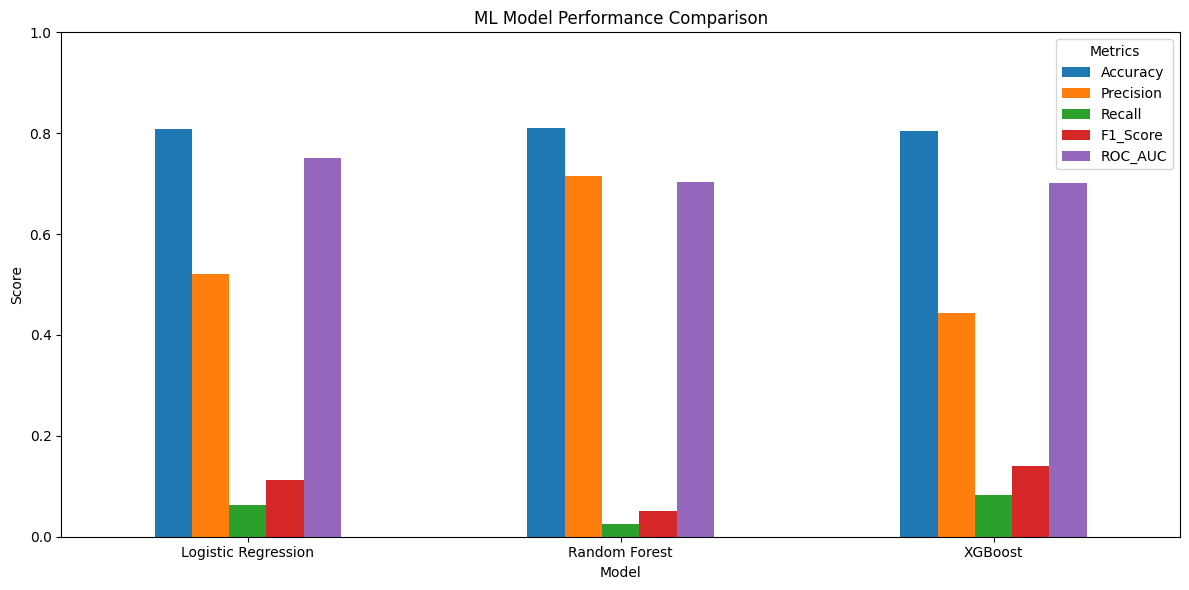

In [96]:
# ==========================================
# STEP 11.2 — Model Performance Comparison
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [97]:
# ==========================================
# STEP 11.3 — Churn Class Comparison
# ==========================================

churn_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [
        logistic_results["Precision"],
        rf_results["Precision"],
        xgb_results["Precision"]
    ],
    "Recall": [
        logistic_results["Recall"],
        rf_results["Recall"],
        xgb_results["Recall"]
    ],
    "F1_Score": [
        logistic_results["F1_Score"],
        rf_results["F1_Score"],
        xgb_results["F1_Score"]
    ],
    "ROC_AUC": [
        logistic_results["ROC_AUC"],
        rf_results["ROC_AUC"],
        xgb_results["ROC_AUC"]
    ]
})

churn_comparison.round(4)

,Model,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.5217,0.0625,0.1116,0.7506
1,Random Forest,0.7143,0.0260,0.0503,0.7026
2,XGBoost,0.4444,0.0833,0.1404,0.7017


In [98]:
# ==========================================
# STEP 11.4 — Highest F1 Score
# ==========================================

best_f1_model = results_df.loc[
    results_df["F1_Score"].idxmax(),
    "Model"
]

best_f1_score = results_df["F1_Score"].max()

print("Highest F1 Score Model:", best_f1_model)
print("F1 Score:", round(best_f1_score, 4))

Highest F1 Score Model: XGBoost
F1 Score: 0.1404


In [99]:
# ==========================================
# STEP 11.5 — Highest ROC-AUC
# ==========================================

best_auc_model = results_df.loc[
    results_df["ROC_AUC"].idxmax(),
    "Model"
]

best_auc_score = results_df["ROC_AUC"].max()

print("Highest ROC-AUC Model:", best_auc_model)
print("ROC-AUC:", round(best_auc_score, 4))

Highest ROC-AUC Model: Logistic Regression
ROC-AUC: 0.7506


In [100]:
# ==========================================
# STEP 11.8 — Model Selection Summary
# ==========================================

print("========== MODEL COMPARISON ==========\n")

print(results_df.to_string(index=False))

print("\n========== KEY RESULTS ==========\n")

print(
    f"Highest F1 Score: {best_f1_model} "
    f"({best_f1_score:.4f})"
)

print(
    f"Highest ROC-AUC: {best_auc_model} "
    f"({best_auc_score:.4f})"
)

========== MODEL COMPARISON ==========

              Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
Logistic Regression     0.809     0.5217  0.0625    0.1116   0.7506
      Random Forest     0.811     0.7143  0.0260    0.0503   0.7026
            XGBoost     0.804     0.4444  0.0833    0.1404   0.7017

========== KEY RESULTS ==========

Highest F1 Score: XGBoost (0.1404)
Highest ROC-AUC: Logistic Regression (0.7506)


In [101]:
# ==========================================
# STEP 11.9 — Selected Model
# ==========================================

selected_model_name = best_f1_model

print("Selected Model:", selected_model_name)

Selected Model: XGBoost


In [102]:
# ==========================================
# STEP 11.10 — Selected Model Pipeline
# ==========================================

model_pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline
}

selected_model = model_pipelines[selected_model_name]

print("Selected pipeline:", selected_model_name)

Selected pipeline: XGBoost


In [103]:
# ==========================================
# STEP 12.1 — Customer-Level Predictions
# ==========================================

# Get the original customer IDs for the test customers
test_customer_ids = df.loc[X_test.index, "Customer_ID"]

predictions_df = X_test.copy()

predictions_df["Customer_ID"] = test_customer_ids

predictions_df["Churn_Probability"] = xgb_prob

predictions_df["Predicted_Churn"] = xgb_pred

predictions_df.head()

,Age,Gender,Region,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,Favorite_Genre,...,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Account_Creation_Year,Account_Creation_Month,Account_Creation_Day,Customer_ID,Churn_Probability,Predicted_Churn
2358,33,Male,Europe,Premium,20.00,Direct Debit,Yes,Annual,8.4,Sci-Fi,...,9,0,2,20,2025,10,22,CUST_3359,0.151851,0
3812,32,Female,North America,Standard,13.89,Credit Card,Yes,Monthly,6.2,Thriller,...,8,1,2,25,2023,2,8,CUST_4813,0.313774,0
4442,37,Male,Middle East & Africa,Premium,19.33,Credit Card,Yes,Monthly,24.6,Sci-Fi,...,18,0,3,9,2021,5,22,CUST_5443,0.052850,0
3744,19,Female,Asia Pacific,Basic,8.28,PayPal,Yes,Annual,8.4,Thriller,...,7,1,2,20,2022,4,26,CUST_4745,0.069850,0
1275,55,Female,Asia Pacific,Basic,8.61,Credit Card,Yes,Monthly,2.2,Family,...,5,1,1,20,2021,11,10,CUST_2276,0.120502,0


In [104]:
# ==========================================
# STEP 12.2 — Churn Prediction Label
# ==========================================

predictions_df["Churn_Prediction"] = predictions_df[
    "Predicted_Churn"
].map({
    0: "Active",
    1: "Churned"
})

predictions_df[
    [
        "Customer_ID",
        "Churn_Probability",
        "Churn_Prediction"
    ]
].head(10)

,Customer_ID,Churn_Probability,Churn_Prediction
2358,CUST_3359,0.151851,Active
3812,CUST_4813,0.313774,Active
4442,CUST_5443,0.052850,Active
3744,CUST_4745,0.069850,Active
1275,CUST_2276,0.120502,Active
4025,CUST_5026,0.298337,Active
2753,CUST_3754,0.087337,Active
1086,CUST_2087,0.129137,Active
2805,CUST_3806,0.186879,Active
1918,CUST_2919,0.063695,Active


In [105]:
# ==========================================
# STEP 12.3 — Risk Level
# ==========================================

def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"


predictions_df["Risk_Level"] = predictions_df[
    "Churn_Probability"
].apply(risk_level)

predictions_df[
    [
        "Customer_ID",
        "Churn_Probability",
        "Churn_Prediction",
        "Risk_Level"
    ]
].head(10)

,Customer_ID,Churn_Probability,Churn_Prediction,Risk_Level
2358,CUST_3359,0.151851,Active,Low
3812,CUST_4813,0.313774,Active,Medium
4442,CUST_5443,0.052850,Active,Low
3744,CUST_4745,0.069850,Active,Low
1275,CUST_2276,0.120502,Active,Low
4025,CUST_5026,0.298337,Active,Low
2753,CUST_3754,0.087337,Active,Low
1086,CUST_2087,0.129137,Active,Low
2805,CUST_3806,0.186879,Active,Low
1918,CUST_2919,0.063695,Active,Low


In [106]:
# ==========================================
# STEP 12.4 — Churn Probability %
# ==========================================

predictions_df["Churn_Probability_Pct"] = (
    predictions_df["Churn_Probability"] * 100
).round(2)

predictions_df[
    [
        "Customer_ID",
        "Churn_Probability_Pct",
        "Risk_Level"
    ]
].head(10)

,Customer_ID,Churn_Probability_Pct,Risk_Level
2358,CUST_3359,15.190000,Low
3812,CUST_4813,31.379999,Medium
4442,CUST_5443,5.290000,Low
3744,CUST_4745,6.990000,Low
1275,CUST_2276,12.050000,Low
4025,CUST_5026,29.830000,Low
2753,CUST_3754,8.730000,Low
1086,CUST_2087,12.910000,Low
2805,CUST_3806,18.690001,Low
1918,CUST_2919,6.370000,Low


In [107]:
# ==========================================
# STEP 12.5 — Expected Monthly Revenue Risk
# ==========================================

predictions_df["Expected_Monthly_Revenue_Risk"] = (
    predictions_df["Monthly_Charges"]
    * predictions_df["Churn_Probability"]
)

predictions_df[
    [
        "Customer_ID",
        "Monthly_Charges",
        "Churn_Probability_Pct",
        "Expected_Monthly_Revenue_Risk"
    ]
].head(10)

,Customer_ID,Monthly_Charges,Churn_Probability_Pct,Expected_Monthly_Revenue_Risk
2358,CUST_3359,20.00,15.190000,3.037010
3812,CUST_4813,13.89,31.379999,4.358321
4442,CUST_5443,19.33,5.290000,1.021599
3744,CUST_4745,8.28,6.990000,0.578359
1275,CUST_2276,8.61,12.050000,1.037523
4025,CUST_5026,20.56,29.830000,6.133811
2753,CUST_3754,7.86,8.730000,0.686465
1086,CUST_2087,14.42,12.910000,1.862151
2805,CUST_3806,7.73,18.690001,1.444573
1918,CUST_2919,14.12,6.370000,0.899371


In [108]:
# ==========================================
# STEP 12.6 — Final Prediction Dataset
# ==========================================

final_predictions = predictions_df[
    [
        "Customer_ID",
        "Age",
        "Gender",
        "Region",
        "Subscription_Plan",
        "Monthly_Charges",
        "Payment_Method",
        "Auto_Renewal",
        "Contract_Length",
        "Average_Watch_Hours_Per_Week",
        "Devices_Registered",
        "Login_Frequency_Per_Week",
        "Download_For_Offline_Count",
        "Customer_Support_Calls",
        "Streaming_Quality_Issues",
        "Days_Since_Last_Login",
        "Churn_Probability",
        "Churn_Probability_Pct",
        "Predicted_Churn",
        "Churn_Prediction",
        "Risk_Level",
        "Expected_Monthly_Revenue_Risk"
    ]
].copy()

final_predictions.head()

,Customer_ID,Age,Gender,Region,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,...,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Churn_Probability,Churn_Probability_Pct,Predicted_Churn,Churn_Prediction,Risk_Level,Expected_Monthly_Revenue_Risk
2358,CUST_3359,33,Male,Europe,Premium,20.00,Direct Debit,Yes,Annual,8.4,...,9,0,2,20,0.151851,15.190000,0,Active,Low,3.037010
3812,CUST_4813,32,Female,North America,Standard,13.89,Credit Card,Yes,Monthly,6.2,...,8,1,2,25,0.313774,31.379999,0,Active,Medium,4.358321
4442,CUST_5443,37,Male,Middle East & Africa,Premium,19.33,Credit Card,Yes,Monthly,24.6,...,18,0,3,9,0.052850,5.290000,0,Active,Low,1.021599
3744,CUST_4745,19,Female,Asia Pacific,Basic,8.28,PayPal,Yes,Annual,8.4,...,7,1,2,20,0.069850,6.990000,0,Active,Low,0.578359
1275,CUST_2276,55,Female,Asia Pacific,Basic,8.61,Credit Card,Yes,Monthly,2.2,...,5,1,1,20,0.120502,12.050000,0,Active,Low,1.037523


In [109]:
# ==========================================
# STEP 12.7 — Risk Distribution
# ==========================================

print(
    final_predictions["Risk_Level"]
    .value_counts()
)

print("\nRisk Percentage:")
print(
    final_predictions["Risk_Level"]
    .value_counts(normalize=True) * 100
)

Risk_Level
Low       814
Medium    177
High        9
Name: count, dtype: int64

Risk Percentage:
Risk_Level
Low       81.4
Medium    17.7
High       0.9
Name: proportion, dtype: float64


In [110]:
# ==========================================
# STEP 12.8 — Highest Risk Customers
# ==========================================

high_risk_customers = final_predictions.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk_customers[
    [
        "Customer_ID",
        "Subscription_Plan",
        "Monthly_Charges",
        "Churn_Probability_Pct",
        "Risk_Level",
        "Expected_Monthly_Revenue_Risk"
    ]
].head(20)

,Customer_ID,Subscription_Plan,Monthly_Charges,Churn_Probability_Pct,Risk_Level,Expected_Monthly_Revenue_Risk
4793,CUST_5794,Premium,19.99,76.110001,High,15.215145
4146,CUST_5147,Basic,7.62,70.199997,High,5.349193
712,CUST_1713,Premium,20.05,68.910004,High,13.816614
2220,CUST_3221,Standard,14.12,68.580002,High,9.682967
3717,CUST_4718,Premium,20.00,66.070000,High,13.213816
1702,CUST_2703,Standard,13.83,65.370003,High,9.040699
2553,CUST_3554,Premium,20.50,63.529999,High,13.023598
2979,CUST_3980,Premium,19.91,63.380001,High,12.619734
3179,CUST_4180,Standard,14.52,60.270000,High,8.750621
472,CUST_1473,Basic,8.09,59.950001,Medium,4.850032


In [111]:
# ==========================================
# STEP 12.9 — Revenue Risk
# ==========================================

total_revenue_risk = (
    final_predictions[
        "Expected_Monthly_Revenue_Risk"
    ].sum()
)

print(
    "Expected Monthly Revenue at Risk:",
    round(total_revenue_risk, 2)
)

Expected Monthly Revenue at Risk: 2527.64


In [112]:
# ==========================================
# STEP 12.10 — Risk Summary
# ==========================================

risk_summary = (
    final_predictions
    .groupby("Risk_Level")
    .agg(
        Customers=("Customer_ID", "count"),
        Avg_Churn_Probability=("Churn_Probability", "mean"),
        Revenue_at_Risk=("Expected_Monthly_Revenue_Risk", "sum")
    )
    .reset_index()
)

risk_summary["Avg_Churn_Probability"] = (
    risk_summary["Avg_Churn_Probability"] * 100
).round(2)

risk_summary["Revenue_at_Risk"] = (
    risk_summary["Revenue_at_Risk"].round(2)
)

risk_summary

,Risk_Level,Customers,Avg_Churn_Probability,Revenue_at_Risk
0,High,9,66.940002,100.71
1,Low,814,13.390000,1408.79
2,Medium,177,39.970001,1018.14


In [113]:
# ==========================================
# STEP 12.11 — Export ML Predictions
# ==========================================

output_path = "/content/OTT_Churn_ML_Predictions.csv"

final_predictions.to_csv(
    output_path,
    index=False
)

print("ML prediction file saved successfully!")
print(output_path)

ML prediction file saved successfully!
/content/OTT_Churn_ML_Predictions.csv


In [114]:
# ==========================================
# STEP 12.12 — Verify Export
# ==========================================

check_df = pd.read_csv(output_path)

print("Shape:", check_df.shape)

check_df.head()

Shape: (1000, 22)


,Customer_ID,Age,Gender,Region,Subscription_Plan,Monthly_Charges,Payment_Method,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,...,Download_For_Offline_Count,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login,Churn_Probability,Churn_Probability_Pct,Predicted_Churn,Churn_Prediction,Risk_Level,Expected_Monthly_Revenue_Risk
0,CUST_3359,33,Male,Europe,Premium,20.00,Direct Debit,Yes,Annual,8.4,...,9,0,2,20,0.151851,15.19,0,Active,Low,3.037010
1,CUST_4813,32,Female,North America,Standard,13.89,Credit Card,Yes,Monthly,6.2,...,8,1,2,25,0.313774,31.38,0,Active,Medium,4.358321
2,CUST_5443,37,Male,Middle East & Africa,Premium,19.33,Credit Card,Yes,Monthly,24.6,...,18,0,3,9,0.052850,5.29,0,Active,Low,1.021599
3,CUST_4745,19,Female,Asia Pacific,Basic,8.28,PayPal,Yes,Annual,8.4,...,7,1,2,20,0.069850,6.99,0,Active,Low,0.578359
4,CUST_2276,55,Female,Asia Pacific,Basic,8.61,Credit Card,Yes,Monthly,2.2,...,5,1,1,20,0.120502,12.05,0,Active,Low,1.037523


In [115]:
!pip install -q shap

In [116]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [117]:
# Get preprocessing and XGBoost model
preprocessor_fitted = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of features:", len(feature_names))
print("Transformed shape:", X_test_transformed.shape)

Number of features: 37
Transformed shape: (1000, 37)


In [118]:
# ==========================================
# STEP 12.13 — SHAP Explainer
# ==========================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values generated successfully!")
print("SHAP shape:", shap_values.shape)

SHAP values generated successfully!
SHAP shape: (1000, 37)


In [119]:
# ==========================================
# STEP 12.14 — Global SHAP Feature Importance
# ==========================================

# Calculate mean absolute SHAP value
mean_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance DataFrame
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_shap
})

# Sort from most important to least important
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Display top 20 features
shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
0,numerical__Average_Watch_Hours_Per_Week,0.326106
1,numerical__Days_Since_Last_Login,0.322388
2,numerical__Login_Frequency_Per_Week,0.263011
3,numerical__Monthly_Charges,0.221632
4,categorical__Contract_Length_Annual,0.153925
5,numerical__Streaming_Quality_Issues,0.131035
6,numerical__Age,0.114373
7,numerical__Download_For_Offline_Count,0.105041
8,numerical__Devices_Registered,0.096447
9,numerical__Customer_Support_Calls,0.085000


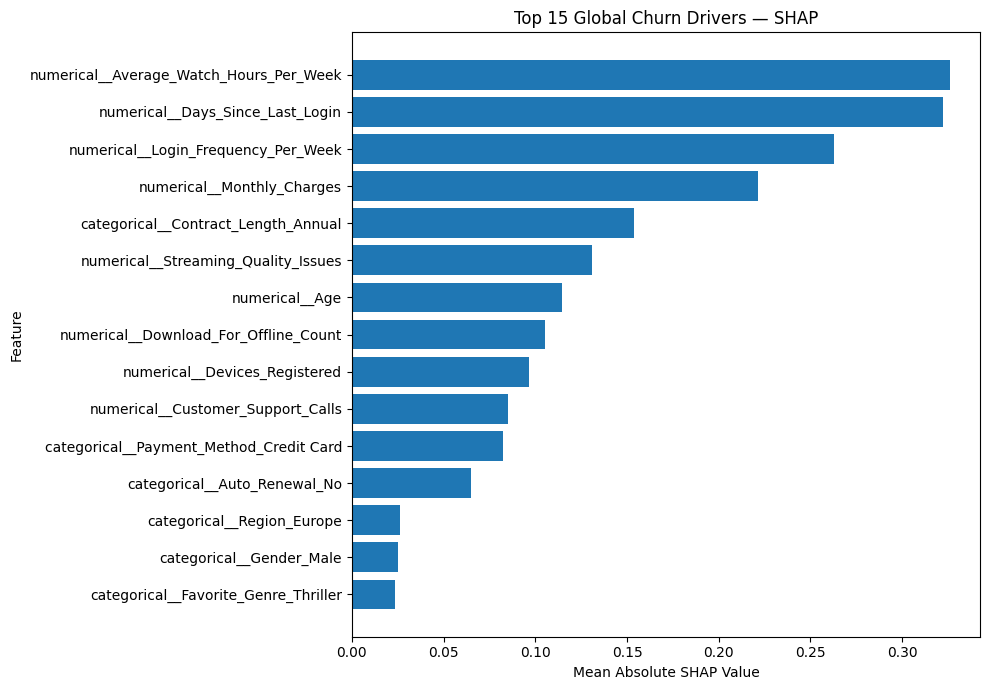

In [120]:
# ==========================================
# STEP 12.15 — Global SHAP Importance Chart
# ==========================================

top_features = shap_importance.head(15).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Global Churn Drivers — SHAP")

plt.tight_layout()
plt.show()

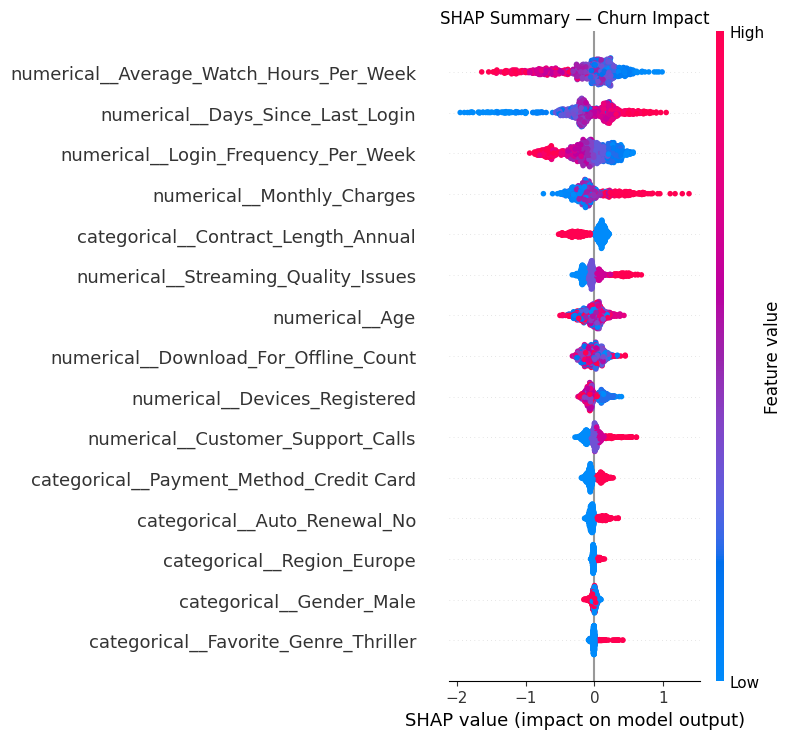

In [121]:
# ==========================================
# STEP 12.16 — SHAP Summary Plot
# ==========================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — Churn Impact")
plt.tight_layout()
plt.show()

In [122]:
print(X_test.index[:10])
print(X_test.shape)

Index([2358, 3812, 4442, 3744, 1275, 4025, 2753, 1086, 2805, 1918], dtype='int64')
(1000, 19)


In [123]:
print(X_test.columns.tolist())

['Age', 'Gender', 'Region', 'Subscription_Plan', 'Monthly_Charges', 'Payment_Method', 'Auto_Renewal', 'Contract_Length', 'Average_Watch_Hours_Per_Week', 'Favorite_Genre', 'Devices_Registered', 'Login_Frequency_Per_Week', 'Download_For_Offline_Count', 'Customer_Support_Calls', 'Streaming_Quality_Issues', 'Days_Since_Last_Login', 'Account_Creation_Year', 'Account_Creation_Month', 'Account_Creation_Day']


In [124]:
customer_idx = 0

X_customer = X_test.iloc[[customer_idx]]

print("Customer index:", X_customer.index[0])
print(X_customer)

Customer index: 2358
      Age Gender  Region Subscription_Plan  Monthly_Charges Payment_Method  \
2358   33   Male  Europe           Premium             20.0   Direct Debit   

     Auto_Renewal Contract_Length  Average_Watch_Hours_Per_Week  \
2358          Yes          Annual                           8.4   

     Favorite_Genre  Devices_Registered  Login_Frequency_Per_Week  \
2358         Sci-Fi                   7                         7   

      Download_For_Offline_Count  Customer_Support_Calls  \
2358                           9                       0   

      Streaming_Quality_Issues  Days_Since_Last_Login  Account_Creation_Year  \
2358                         2                     20                   2025   

      Account_Creation_Month  Account_Creation_Day  
2358                      10                    22  


In [125]:
prediction = xgb_pipeline.predict(X_customer)[0]

churn_probability = xgb_pipeline.predict_proba(X_customer)[0][1]

prediction_label = (
    "High Churn Risk" if prediction == 1
    else "Low Churn Risk"
)

print("Prediction:", prediction_label)
print("Churn Probability:", f"{churn_probability:.2%}")

Prediction: Low Churn Risk
Churn Probability: 15.19%


In [126]:
preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

X_customer_processed = preprocessor.transform(X_customer)

explainer = shap.TreeExplainer(xgb_model)

customer_shap = explainer(X_customer_processed)

In [127]:
feature_names = preprocessor.get_feature_names_out()

shap_values = customer_shap.values[0]

customer_values = (
    X_customer_processed.toarray()[0]
    if hasattr(X_customer_processed, "toarray")
    else X_customer_processed[0]
)

explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": customer_values,
    "SHAP_Value": shap_values
})

explanation_df["Impact"] = explanation_df["SHAP_Value"].apply(
    lambda x: "Increases Churn" if x > 0
    else "Decreases Churn"
)

explanation_df = explanation_df.sort_values(
    "SHAP_Value",
    key=abs,
    ascending=False
)

explanation_df.head(10)

,Feature,Feature_Value,SHAP_Value,Impact
18,categorical__Contract_Length_Annual,1.0,-0.381540,Decreases Churn
29,numerical__Monthly_Charges,20.0,0.340324,Increases Churn
32,numerical__Login_Frequency_Per_Week,7.0,-0.303987,Decreases Churn
30,numerical__Average_Watch_Hours_Per_Week,8.4,0.188170,Increases Churn
36,numerical__Days_Since_Last_Login,20.0,-0.170043,Decreases Churn
35,numerical__Streaming_Quality_Issues,2.0,0.098081,Increases Churn
31,numerical__Devices_Registered,7.0,0.083514,Increases Churn
34,numerical__Customer_Support_Calls,0.0,-0.083373,Decreases Churn
4,categorical__Region_Europe,1.0,0.058087,Increases Churn
33,numerical__Download_For_Offline_Count,9.0,0.057029,Increases Churn


In [128]:
print("Customer index:", X_customer.index[0])
print("Prediction:", prediction_label)
print("Churn Probability:", f"{churn_probability:.2%}")

display(explanation_df.head(10))

Customer index: 2358
Prediction: Low Churn Risk
Churn Probability: 15.19%


,Feature,Feature_Value,SHAP_Value,Impact
18,categorical__Contract_Length_Annual,1.0,-0.381540,Decreases Churn
29,numerical__Monthly_Charges,20.0,0.340324,Increases Churn
32,numerical__Login_Frequency_Per_Week,7.0,-0.303987,Decreases Churn
30,numerical__Average_Watch_Hours_Per_Week,8.4,0.188170,Increases Churn
36,numerical__Days_Since_Last_Login,20.0,-0.170043,Decreases Churn
35,numerical__Streaming_Quality_Issues,2.0,0.098081,Increases Churn
31,numerical__Devices_Registered,7.0,0.083514,Increases Churn
34,numerical__Customer_Support_Calls,0.0,-0.083373,Decreases Churn
4,categorical__Region_Europe,1.0,0.058087,Increases Churn
33,numerical__Download_For_Offline_Count,9.0,0.057029,Increases Churn


In [129]:
def explain_customer(customer_idx):

    # Select customer
    X_customer = X_test.iloc[[customer_idx]]

    # Prediction
    prediction = xgb_pipeline.predict(X_customer)[0]
    churn_probability = xgb_pipeline.predict_proba(X_customer)[0][1]

    prediction_label = (
        "High Churn Risk"
        if prediction == 1
        else "Low Churn Risk"
    )

    # Preprocessing
    X_customer_processed = preprocessor.transform(X_customer)

    # SHAP
    customer_shap = explainer(X_customer_processed)

    feature_names = preprocessor.get_feature_names_out()
    shap_values = customer_shap.values[0]

    customer_values = (
        X_customer_processed.toarray()[0]
        if hasattr(X_customer_processed, "toarray")
        else X_customer_processed[0]
    )

    # Explanation table
    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "Feature_Value": customer_values,
        "SHAP_Value": shap_values
    })

    explanation_df["Impact"] = explanation_df["SHAP_Value"].apply(
        lambda x: "Increases Churn"
        if x > 0
        else "Decreases Churn"
    )

    # Churn drivers
    top_churn_drivers = (
        explanation_df[explanation_df["SHAP_Value"] > 0]
        .sort_values("SHAP_Value", ascending=False)
        .head(5)
    )

    # Retention factors
    top_retention_factors = (
        explanation_df[explanation_df["SHAP_Value"] < 0]
        .sort_values("SHAP_Value", ascending=True)
        .head(5)
    )

    # Final output
    print("=" * 60)
    print("INDIVIDUAL CUSTOMER EXPLANATION")
    print("=" * 60)

    print(f"\nCustomer Index: {customer_idx}")
    print(f"Prediction: {prediction_label}")
    print(f"Churn Probability: {churn_probability:.2%}")

    print("\nTop Churn Drivers:")
    for i, row in enumerate(top_churn_drivers.itertuples(), 1):
        print(
            f"{i}. {row.Feature} "
            f"(SHAP: +{row.SHAP_Value:.4f})"
        )

    print("\nTop Retention Factors:")
    for i, row in enumerate(top_retention_factors.itertuples(), 1):
        print(
            f"{i}. {row.Feature} "
            f"(SHAP: {row.SHAP_Value:.4f})"
        )

    print("=" * 60)

    return explanation_df

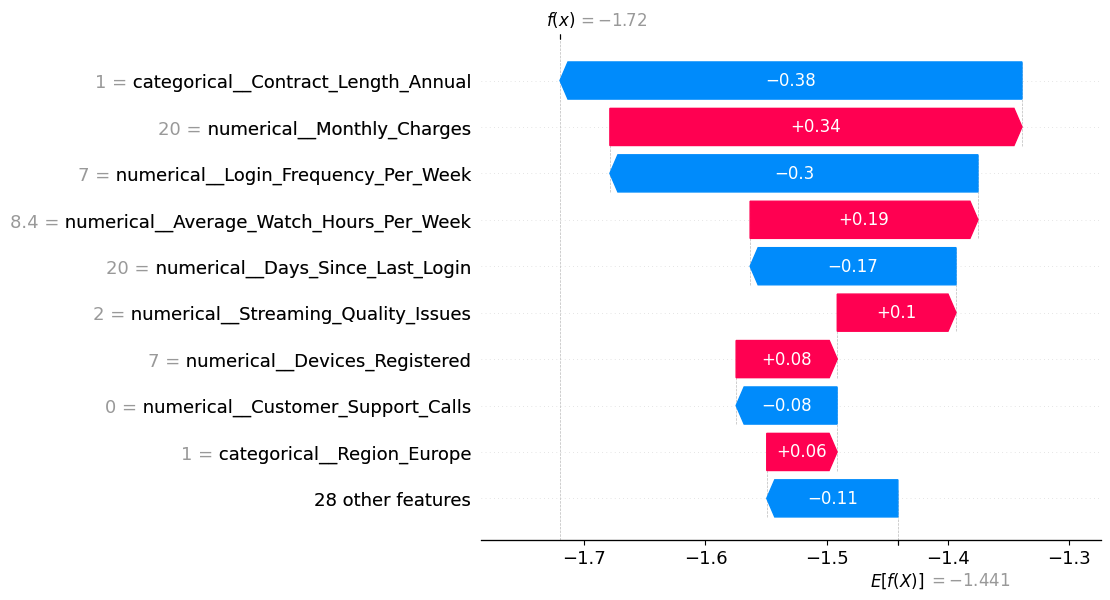

In [130]:
# ============================================
# STEP 12.18 — CUSTOMER SHAP WATERFALL
# ============================================

customer_idx = 0

# Select customer
X_customer = X_test.iloc[[customer_idx]]

# Transform using the SAME preprocessing pipeline
X_customer_processed = preprocessor.transform(X_customer)

# Create SHAP explanation
customer_shap = explainer(X_customer_processed)

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Create Explanation object with feature names
customer_explanation = shap.Explanation(
    values=customer_shap.values[0],
    base_values=customer_shap.base_values[0],
    data=(
        X_customer_processed.toarray()[0]
        if hasattr(X_customer_processed, "toarray")
        else X_customer_processed[0]
    ),
    feature_names=feature_names
)

# Plot waterfall
shap.plots.waterfall(
    customer_explanation,
    max_display=10
)

In [131]:
# ============================================
# STEP 12.19 — EXPORT SHAP RESULTS
# ============================================

# Transform all test data
X_test_processed = preprocessor.transform(X_test)

# Generate SHAP explanations
all_shap = explainer(X_test_processed)

# Feature names
feature_names = preprocessor.get_feature_names_out()

print("SHAP calculation completed.")
print("SHAP shape:", all_shap.values.shape)
print("Number of test customers:", len(X_test))
print("Number of features:", len(feature_names))

SHAP calculation completed.
SHAP shape: (1000, 37)
Number of test customers: 1000
Number of features: 37


In [132]:
# ============================================
# STEP 12.19.1 — CREATE SHAP RESULTS TABLE
# ============================================

# Get SHAP values
shap_values = all_shap.values

# Get processed feature values
processed_values = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

# Create long-format SHAP table
shap_results = pd.DataFrame({
    "Customer_Index": X_test.index.repeat(len(feature_names)),
    "Feature": feature_names.tolist() * len(X_test),
    "Feature_Value": processed_values.flatten(),
    "SHAP_Value": shap_values.flatten()
})

# Add impact
shap_results["Impact"] = shap_results["SHAP_Value"].apply(
    lambda x: "Increases Churn" if x > 0 else "Decreases Churn"
)

print("SHAP Results Shape:", shap_results.shape)
shap_results.head(10)

SHAP Results Shape: (37000, 5)


,Customer_Index,Feature,Feature_Value,SHAP_Value,Impact
0,2358,categorical__Gender_Female,0.0,-0.054773,Decreases Churn
1,2358,categorical__Gender_Male,1.0,-0.001246,Decreases Churn
2,2358,categorical__Gender_Other,0.0,-0.001302,Decreases Churn
3,2358,categorical__Region_Asia Pacific,0.0,-0.011320,Decreases Churn
4,2358,categorical__Region_Europe,1.0,0.058087,Increases Churn
5,2358,categorical__Region_Latin America,0.0,-0.004603,Decreases Churn
6,2358,categorical__Region_Middle East & Africa,0.0,-0.002496,Decreases Churn
7,2358,categorical__Region_North America,0.0,0.006835,Increases Churn
8,2358,categorical__Subscription_Plan_Basic,0.0,0.003817,Increases Churn
9,2358,categorical__Subscription_Plan_Premium,1.0,0.052345,Increases Churn


In [133]:
# ============================================
# STEP 12.19.2 — ADD PREDICTION & PROBABILITY
# ============================================

# Predictions for all test customers
predictions = xgb_pipeline.predict(X_test)

# Churn probabilities
churn_probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]

# Create customer-level prediction table
customer_predictions = pd.DataFrame({
    "Customer_Index": X_test.index,
    "Prediction": predictions,
    "Churn_Probability": churn_probabilities
})

# Convert prediction to business-friendly label
customer_predictions["Risk_Level"] = customer_predictions["Prediction"].apply(
    lambda x: "High Churn Risk" if x == 1 else "Low Churn Risk"
)

# Merge with SHAP results
shap_results = shap_results.merge(
    customer_predictions,
    on="Customer_Index",
    how="left"
)

print("Updated SHAP Results Shape:", shap_results.shape)

shap_results.head(10)

Updated SHAP Results Shape: (37000, 8)


,Customer_Index,Feature,Feature_Value,SHAP_Value,Impact,Prediction,Churn_Probability,Risk_Level
0,2358,categorical__Gender_Female,0.0,-0.054773,Decreases Churn,0,0.151851,Low Churn Risk
1,2358,categorical__Gender_Male,1.0,-0.001246,Decreases Churn,0,0.151851,Low Churn Risk
2,2358,categorical__Gender_Other,0.0,-0.001302,Decreases Churn,0,0.151851,Low Churn Risk
3,2358,categorical__Region_Asia Pacific,0.0,-0.011320,Decreases Churn,0,0.151851,Low Churn Risk
4,2358,categorical__Region_Europe,1.0,0.058087,Increases Churn,0,0.151851,Low Churn Risk
5,2358,categorical__Region_Latin America,0.0,-0.004603,Decreases Churn,0,0.151851,Low Churn Risk
6,2358,categorical__Region_Middle East & Africa,0.0,-0.002496,Decreases Churn,0,0.151851,Low Churn Risk
7,2358,categorical__Region_North America,0.0,0.006835,Increases Churn,0,0.151851,Low Churn Risk
8,2358,categorical__Subscription_Plan_Basic,0.0,0.003817,Increases Churn,0,0.151851,Low Churn Risk
9,2358,categorical__Subscription_Plan_Premium,1.0,0.052345,Increases Churn,0,0.151851,Low Churn Risk


In [134]:
# ============================================
# STEP 12.19.3 — CLEAN FEATURE NAMES
# ============================================

def clean_feature_name(feature):
    # Remove preprocessing prefixes
    feature = feature.replace("categorical__", "")
    feature = feature.replace("numerical__", "")

    return feature


shap_results["Business_Feature"] = (
    shap_results["Feature"]
    .apply(clean_feature_name)
)

# Round numerical values
shap_results["Feature_Value"] = shap_results["Feature_Value"].round(4)
shap_results["SHAP_Value"] = shap_results["SHAP_Value"].round(6)
shap_results["Churn_Probability"] = (
    shap_results["Churn_Probability"].round(4)
)

# Reorder columns
shap_results = shap_results[
    [
        "Customer_Index",
        "Prediction",
        "Churn_Probability",
        "Risk_Level",
        "Feature",
        "Business_Feature",
        "Feature_Value",
        "SHAP_Value",
        "Impact"
    ]
]

print("Final SHAP Table Shape:", shap_results.shape)

shap_results.head(10)

Final SHAP Table Shape: (37000, 9)


,Customer_Index,Prediction,Churn_Probability,Risk_Level,Feature,Business_Feature,Feature_Value,SHAP_Value,Impact
0,2358,0,0.1519,Low Churn Risk,categorical__Gender_Female,Gender_Female,0.0,-0.054773,Decreases Churn
1,2358,0,0.1519,Low Churn Risk,categorical__Gender_Male,Gender_Male,1.0,-0.001246,Decreases Churn
2,2358,0,0.1519,Low Churn Risk,categorical__Gender_Other,Gender_Other,0.0,-0.001302,Decreases Churn
3,2358,0,0.1519,Low Churn Risk,categorical__Region_Asia Pacific,Region_Asia Pacific,0.0,-0.011320,Decreases Churn
4,2358,0,0.1519,Low Churn Risk,categorical__Region_Europe,Region_Europe,1.0,0.058087,Increases Churn
5,2358,0,0.1519,Low Churn Risk,categorical__Region_Latin America,Region_Latin America,0.0,-0.004603,Decreases Churn
6,2358,0,0.1519,Low Churn Risk,categorical__Region_Middle East & Africa,Region_Middle East & Africa,0.0,-0.002496,Decreases Churn
7,2358,0,0.1519,Low Churn Risk,categorical__Region_North America,Region_North America,0.0,0.006835,Increases Churn
8,2358,0,0.1519,Low Churn Risk,categorical__Subscription_Plan_Basic,Subscription_Plan_Basic,0.0,0.003817,Increases Churn
9,2358,0,0.1519,Low Churn Risk,categorical__Subscription_Plan_Premium,Subscription_Plan_Premium,1.0,0.052345,Increases Churn


In [135]:
# ============================================
# STEP 12.19.4 — FINAL CSV EXPORT
# ============================================

output_file = "OTT_SHAP_Results.csv"

shap_results.to_csv(
    output_file,
    index=False
)

print("SHAP results exported successfully!")
print("File:", output_file)
print("Rows:", len(shap_results))
print("Columns:", len(shap_results.columns))

SHAP results exported successfully!
File: OTT_SHAP_Results.csv
Rows: 37000
Columns: 9


# **done**

In [136]:

# ============================================
# PAGE 4 — STEP 4.1
# CREATE CUSTOMER-LEVEL ML PREDICTIONS
# ============================================

# Get predictions
predictions = xgb_pipeline.predict(X_test)

# Get churn probabilities
churn_probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]

# Create customer-level table
ml_predictions = pd.DataFrame({
    "Customer_Index": X_test.index,
    "Prediction": predictions,
    "Churn_Probability": churn_probabilities
})

print("ML Prediction Table Shape:", ml_predictions.shape)

ml_predictions.head(10)

ML Prediction Table Shape: (1000, 3)


,Customer_Index,Prediction,Churn_Probability
0,2358,0,0.151851
1,3812,0,0.313774
2,4442,0,0.052850
3,3744,0,0.069850
4,1275,0,0.120502
5,4025,0,0.298337
6,2753,0,0.087337
7,1086,0,0.129137
8,2805,0,0.186879
9,1918,0,0.063695


In [137]:
# ============================================
# CREATE RISK LEVEL
# ============================================

ml_predictions["Risk_Level"] = pd.cut(
    ml_predictions["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

print(ml_predictions["Risk_Level"].value_counts())

ml_predictions.head(10)

Risk_Level
Low Risk       814
Medium Risk    177
High Risk        9
Name: count, dtype: int64


,Customer_Index,Prediction,Churn_Probability,Risk_Level
0,2358,0,0.151851,Low Risk
1,3812,0,0.313774,Medium Risk
2,4442,0,0.052850,Low Risk
3,3744,0,0.069850,Low Risk
4,1275,0,0.120502,Low Risk
5,4025,0,0.298337,Low Risk
6,2753,0,0.087337,Low Risk
7,1086,0,0.129137,Low Risk
8,2805,0,0.186879,Low Risk
9,1918,0,0.063695,Low Risk


In [138]:
# ============================================
# ADD MONTHLY CHARGES
# ============================================

ml_predictions["Monthly_Charges"] = (
    X_test["Monthly_Charges"].values
)

ml_predictions.head(10)

,Customer_Index,Prediction,Churn_Probability,Risk_Level,Monthly_Charges
0,2358,0,0.151851,Low Risk,20.00
1,3812,0,0.313774,Medium Risk,13.89
2,4442,0,0.052850,Low Risk,19.33
3,3744,0,0.069850,Low Risk,8.28
4,1275,0,0.120502,Low Risk,8.61
5,4025,0,0.298337,Low Risk,20.56
6,2753,0,0.087337,Low Risk,7.86
7,1086,0,0.129137,Low Risk,14.42
8,2805,0,0.186879,Low Risk,7.73
9,1918,0,0.063695,Low Risk,14.12


In [139]:
# ============================================
# CALCULATE REVENUE AT RISK
# ============================================

ml_predictions["Revenue_At_Risk"] = (
    ml_predictions["Monthly_Charges"] *
    ml_predictions["Churn_Probability"]
)

ml_predictions["Revenue_At_Risk"] = (
    ml_predictions["Revenue_At_Risk"].round(2)
)

ml_predictions.head(10)

,Customer_Index,Prediction,Churn_Probability,Risk_Level,Monthly_Charges,Revenue_At_Risk
0,2358,0,0.151851,Low Risk,20.00,3.04
1,3812,0,0.313774,Medium Risk,13.89,4.36
2,4442,0,0.052850,Low Risk,19.33,1.02
3,3744,0,0.069850,Low Risk,8.28,0.58
4,1275,0,0.120502,Low Risk,8.61,1.04
5,4025,0,0.298337,Low Risk,20.56,6.13
6,2753,0,0.087337,Low Risk,7.86,0.69
7,1086,0,0.129137,Low Risk,14.42,1.86
8,2805,0,0.186879,Low Risk,7.73,1.44
9,1918,0,0.063695,Low Risk,14.12,0.90


In [140]:
print("Final ML Prediction Table Shape:", ml_predictions.shape)

print("\nColumns:")
print(ml_predictions.columns.tolist())

print("\nRisk Distribution:")
print(ml_predictions["Risk_Level"].value_counts())

ml_predictions.head(10)

Final ML Prediction Table Shape: (1000, 6)

Columns:
['Customer_Index', 'Prediction', 'Churn_Probability', 'Risk_Level', 'Monthly_Charges', 'Revenue_At_Risk']

Risk Distribution:
Risk_Level
Low Risk       814
Medium Risk    177
High Risk        9
Name: count, dtype: int64


,Customer_Index,Prediction,Churn_Probability,Risk_Level,Monthly_Charges,Revenue_At_Risk
0,2358,0,0.151851,Low Risk,20.00,3.04
1,3812,0,0.313774,Medium Risk,13.89,4.36
2,4442,0,0.052850,Low Risk,19.33,1.02
3,3744,0,0.069850,Low Risk,8.28,0.58
4,1275,0,0.120502,Low Risk,8.61,1.04
5,4025,0,0.298337,Low Risk,20.56,6.13
6,2753,0,0.087337,Low Risk,7.86,0.69
7,1086,0,0.129137,Low Risk,14.42,1.86
8,2805,0,0.186879,Low Risk,7.73,1.44
9,1918,0,0.063695,Low Risk,14.12,0.90


In [141]:
# ============================================
# EXPORT PAGE 4 ML DATA
# ============================================

ml_predictions.to_csv(
    "OTT_ML_Customer_Predictions.csv",
    index=False
)

print("Export successful!")
print("File: OTT_ML_Customer_Predictions.csv")

Export successful!
File: OTT_ML_Customer_Predictions.csv


In [142]:
ml_predictions["Subscription_Plan"] = X_test["Subscription_Plan"].values
ml_predictions["Region"] = X_test["Region"].values

In [143]:
ml_predictions.columns

Index(['Customer_Index', 'Prediction', 'Churn_Probability', 'Risk_Level',
       'Monthly_Charges', 'Revenue_At_Risk', 'Subscription_Plan', 'Region'],
      dtype='object')

In [144]:
ml_predictions.to_csv("OTT_ML_Customer_Predictions.csv", index=False)

In [145]:
def generate_recommendation(drivers):

    recommendations = []

    if "Days_Since_Last_Login" in drivers:
        recommendations.append(
            "Send a personalized re-engagement campaign."
        )

    if "Average_Watch_Hours_Per_Week" in drivers:
        recommendations.append(
            "Recommend personalized content to increase engagement."
        )

    if "Customer_Support_Calls" in drivers:
        recommendations.append(
            "Prioritize customer support follow-up."
        )

    if "Monthly_Charges" in drivers:
        recommendations.append(
            "Consider a targeted retention offer."
        )

    return " ".join(recommendations)

In [149]:
# ============================================
# STEP 12.20 — CUSTOMER-LEVEL AI RECOMMENDATIONS
# ============================================

def generate_recommendation(drivers):

    recommendations = []

    drivers = list(drivers)

    if "Days_Since_Last_Login" in drivers:
        recommendations.append(
            "Send a personalized re-engagement campaign."
        )

    if "Average_Watch_Hours_Per_Week" in drivers:
        recommendations.append(
            "Recommend personalized content to increase engagement."
        )

    if "Login_Frequency_Per_Week" in drivers:
        recommendations.append(
            "Encourage regular platform usage through personalized engagement."
        )

    if "Customer_Support_Calls" in drivers:
        recommendations.append(
            "Prioritize customer support follow-up."
        )

    if "Streaming_Quality_Issues" in drivers:
        recommendations.append(
            "Investigate streaming quality issues."
        )

    if "Monthly_Charges" in drivers:
        recommendations.append(
            "Consider a targeted retention offer."
        )

    if "Download_For_Offline_Count" in drivers:
        recommendations.append(
            "Promote offline viewing features."
        )

    if len(recommendations) == 0:
        return "Continue monitoring customer engagement."

    return " ".join(recommendations[:3])

In [150]:
# ============================================
# STEP 12.21 — TOP SHAP DRIVERS PER CUSTOMER
# ============================================

# Only positive SHAP values = drivers increasing churn
positive_shap = shap_results[
    shap_results["SHAP_Value"] > 0
].copy()

# Sort strongest churn drivers first
positive_shap = positive_shap.sort_values(
    ["Customer_Index", "SHAP_Value"],
    ascending=[True, False]
)

# Keep top 5 drivers per customer
top_drivers = (
    positive_shap
    .groupby("Customer_Index")
    .head(5)
)

print("Top driver rows:", len(top_drivers))

top_drivers.head(20)

Top driver rows: 5000


,Customer_Index,Prediction,Churn_Probability,Risk_Level,Feature,Business_Feature,Feature_Value,SHAP_Value,Impact
14929,1,0,0.0753,Low Churn Risk,categorical__Contract_Length_Annual,Contract_Length_Annual,1.0,0.094143,Increases Churn
14939,1,0,0.0753,Low Churn Risk,numerical__Age,Age,46.0,0.087181,Increases Churn
14946,1,0,0.0753,Low Churn Risk,numerical__Streaming_Quality_Issues,Streaming_Quality_Issues,2.0,0.068173,Increases Churn
14947,1,0,0.0753,Low Churn Risk,numerical__Days_Since_Last_Login,Days_Since_Last_Login,10.0,0.066782,Increases Churn
14944,1,0,0.0753,Low Churn Risk,numerical__Download_For_Offline_Count,Download_For_Offline_Count,9.0,0.063514,Increases Churn
15747,4,0,0.0084,Low Churn Risk,categorical__Favorite_Genre_Comedy,Favorite_Genre_Comedy,1.0,0.082650,Increases Churn
15740,4,0,0.0084,Low Churn Risk,categorical__Payment_Method_PayPal,Payment_Method_PayPal,1.0,0.041263,Increases Churn
15743,4,0,0.0084,Low Churn Risk,categorical__Contract_Length_Annual,Contract_Length_Annual,0.0,0.040009,Increases Churn
15759,4,0,0.0084,Low Churn Risk,numerical__Customer_Support_Calls,Customer_Support_Calls,1.0,0.035006,Increases Churn
15742,4,0,0.0084,Low Churn Risk,categorical__Auto_Renewal_Yes,Auto_Renewal_Yes,0.0,0.027669,Increases Churn


In [151]:
# ============================================
# STEP 12.22 — GENERATE AI RECOMMENDATIONS
# ============================================

recommendation_rows = []

for customer_id, group in top_drivers.groupby("Customer_Index"):

    drivers = group["Business_Feature"].tolist()

    recommendation = generate_recommendation(drivers)

    top_driver_1 = drivers[0] if len(drivers) > 0 else "None"
    top_driver_2 = drivers[1] if len(drivers) > 1 else "None"
    top_driver_3 = drivers[2] if len(drivers) > 2 else "None"

    recommendation_rows.append({
        "Customer_Index": customer_id,
        "Top_Driver_1": top_driver_1,
        "Top_Driver_2": top_driver_2,
        "Top_Driver_3": top_driver_3,
        "AI_Recommendation": recommendation
    })

ai_recommendations = pd.DataFrame(recommendation_rows)

print("Recommendation table shape:")
print(ai_recommendations.shape)

ai_recommendations.head(10)

Recommendation table shape:
(1000, 5)


,Customer_Index,Top_Driver_1,Top_Driver_2,Top_Driver_3,AI_Recommendation
0,1,Contract_Length_Annual,Age,Streaming_Quality_Issues,Send a personalized re-engagement campaign. In...
1,4,Favorite_Genre_Comedy,Payment_Method_PayPal,Contract_Length_Annual,Prioritize customer support follow-up.
2,13,Monthly_Charges,Region_Asia Pacific,Age,Consider a targeted retention offer.
3,19,Login_Frequency_Per_Week,Average_Watch_Hours_Per_Week,Devices_Registered,Recommend personalized content to increase eng...
4,20,Days_Since_Last_Login,Login_Frequency_Per_Week,Contract_Length_Annual,Send a personalized re-engagement campaign. En...
5,24,Days_Since_Last_Login,Download_For_Offline_Count,Contract_Length_Annual,Send a personalized re-engagement campaign. Pr...
6,26,Average_Watch_Hours_Per_Week,Auto_Renewal_No,Contract_Length_Annual,Recommend personalized content to increase eng...
7,40,Streaming_Quality_Issues,Payment_Method_Credit Card,Average_Watch_Hours_Per_Week,Recommend personalized content to increase eng...
8,41,Monthly_Charges,Download_For_Offline_Count,Devices_Registered,Consider a targeted retention offer. Promote o...
9,42,Download_For_Offline_Count,Auto_Renewal_No,Auto_Renewal_Yes,Promote offline viewing features.


In [152]:
# ============================================
# STEP 12.23 — FINAL PAGE 5 TABLE
# ============================================

page5_ai = ml_predictions.merge(
    ai_recommendations,
    on="Customer_Index",
    how="left"
)

print("Page 5 table shape:")
print(page5_ai.shape)

page5_ai.head(10)

Page 5 table shape:
(1000, 12)


,Customer_Index,Prediction,Churn_Probability,Risk_Level,Monthly_Charges,Revenue_At_Risk,Subscription_Plan,Region,Top_Driver_1,Top_Driver_2,Top_Driver_3,AI_Recommendation
0,2358,0,0.151851,Low Risk,20.00,3.04,Premium,Europe,Monthly_Charges,Average_Watch_Hours_Per_Week,Streaming_Quality_Issues,Recommend personalized content to increase eng...
1,3812,0,0.313774,Medium Risk,13.89,4.36,Standard,North America,Login_Frequency_Per_Week,Days_Since_Last_Login,Payment_Method_Credit Card,Send a personalized re-engagement campaign. En...
2,4442,0,0.052850,Low Risk,19.33,1.02,Premium,Middle East & Africa,Streaming_Quality_Issues,Payment_Method_Credit Card,Monthly_Charges,Investigate streaming quality issues. Consider...
3,3744,0,0.069850,Low Risk,8.28,0.58,Basic,Asia Pacific,Average_Watch_Hours_Per_Week,Favorite_Genre_Thriller,Streaming_Quality_Issues,Recommend personalized content to increase eng...
4,1275,0,0.120502,Low Risk,8.61,1.04,Basic,Asia Pacific,Login_Frequency_Per_Week,Download_For_Offline_Count,Average_Watch_Hours_Per_Week,Recommend personalized content to increase eng...
5,4025,0,0.298337,Low Risk,20.56,6.13,Premium,North America,Monthly_Charges,Contract_Length_Annual,Days_Since_Last_Login,Send a personalized re-engagement campaign. En...
6,2753,0,0.087337,Low Risk,7.86,0.69,Basic,Europe,Login_Frequency_Per_Week,Days_Since_Last_Login,Age,Send a personalized re-engagement campaign. En...
7,1086,0,0.129137,Low Risk,14.42,1.86,Standard,Europe,Streaming_Quality_Issues,Days_Since_Last_Login,Contract_Length_Annual,Send a personalized re-engagement campaign. In...
8,2805,0,0.186879,Low Risk,7.73,1.44,Basic,Europe,Days_Since_Last_Login,Login_Frequency_Per_Week,Average_Watch_Hours_Per_Week,Send a personalized re-engagement campaign. Re...
9,1918,0,0.063695,Low Risk,14.12,0.90,Standard,Middle East & Africa,Streaming_Quality_Issues,Payment_Method_PayPal,Contract_Length_Monthly,Investigate streaming quality issues.


In [153]:
# ============================================
# STEP 12.24 — ADD CUSTOMER PROFILE
# ============================================

profile_columns = [
    "Age",
    "Gender",
    "Region",
    "Subscription_Plan",
    "Monthly_Charges",
    "Auto_Renewal",
    "Contract_Length",
    "Average_Watch_Hours_Per_Week",
    "Login_Frequency_Per_Week",
    "Customer_Support_Calls",
    "Streaming_Quality_Issues",
    "Days_Since_Last_Login"
]

available_columns = [
    col for col in profile_columns
    if col in X_test.columns
]

customer_profile = X_test[
    available_columns
].copy()

customer_profile["Customer_Index"] = customer_profile.index

page5_ai = page5_ai.merge(
    customer_profile,
    on="Customer_Index",
    how="left",
    suffixes=("", "_Profile")
)

print(page5_ai.shape)

(1000, 24)


In [154]:
# ============================================
# STEP 12.25 — EXPORT FINAL PAGE 5 DATA
# ============================================

page5_ai.to_csv(
    "OTT_Page5_AI_Recommendations.csv",
    index=False
)

print("========================================")
print("PAGE 5 AI DATA CREATED SUCCESSFULLY")
print("========================================")

print("Rows:", len(page5_ai))
print("Columns:", len(page5_ai.columns))

print("\nColumns:")
print(page5_ai.columns.tolist())

print("\nSample:")
display(page5_ai.head(10))

PAGE 5 AI DATA CREATED SUCCESSFULLY
Rows: 1000
Columns: 24

Columns:
['Customer_Index', 'Prediction', 'Churn_Probability', 'Risk_Level', 'Monthly_Charges', 'Revenue_At_Risk', 'Subscription_Plan', 'Region', 'Top_Driver_1', 'Top_Driver_2', 'Top_Driver_3', 'AI_Recommendation', 'Age', 'Gender', 'Region_Profile', 'Subscription_Plan_Profile', 'Monthly_Charges_Profile', 'Auto_Renewal', 'Contract_Length', 'Average_Watch_Hours_Per_Week', 'Login_Frequency_Per_Week', 'Customer_Support_Calls', 'Streaming_Quality_Issues', 'Days_Since_Last_Login']

Sample:


,Customer_Index,Prediction,Churn_Probability,Risk_Level,Monthly_Charges,Revenue_At_Risk,Subscription_Plan,Region,Top_Driver_1,Top_Driver_2,...,Region_Profile,Subscription_Plan_Profile,Monthly_Charges_Profile,Auto_Renewal,Contract_Length,Average_Watch_Hours_Per_Week,Login_Frequency_Per_Week,Customer_Support_Calls,Streaming_Quality_Issues,Days_Since_Last_Login
0,2358,0,0.151851,Low Risk,20.00,3.04,Premium,Europe,Monthly_Charges,Average_Watch_Hours_Per_Week,...,Europe,Premium,20.00,Yes,Annual,8.4,7,0,2,20
1,3812,0,0.313774,Medium Risk,13.89,4.36,Standard,North America,Login_Frequency_Per_Week,Days_Since_Last_Login,...,North America,Standard,13.89,Yes,Monthly,6.2,2,1,2,25
2,4442,0,0.052850,Low Risk,19.33,1.02,Premium,Middle East & Africa,Streaming_Quality_Issues,Payment_Method_Credit Card,...,Middle East & Africa,Premium,19.33,Yes,Monthly,24.6,12,0,3,9
3,3744,0,0.069850,Low Risk,8.28,0.58,Basic,Asia Pacific,Average_Watch_Hours_Per_Week,Favorite_Genre_Thriller,...,Asia Pacific,Basic,8.28,Yes,Annual,8.4,8,1,2,20
4,1275,0,0.120502,Low Risk,8.61,1.04,Basic,Asia Pacific,Login_Frequency_Per_Week,Download_For_Offline_Count,...,Asia Pacific,Basic,8.61,Yes,Monthly,2.2,2,1,1,20
5,4025,0,0.298337,Low Risk,20.56,6.13,Premium,North America,Monthly_Charges,Contract_Length_Annual,...,North America,Premium,20.56,Yes,Monthly,7.3,5,1,0,24
6,2753,0,0.087337,Low Risk,7.86,0.69,Basic,Europe,Login_Frequency_Per_Week,Days_Since_Last_Login,...,Europe,Basic,7.86,Yes,Annual,5.2,4,0,0,27
7,1086,0,0.129137,Low Risk,14.42,1.86,Standard,Europe,Streaming_Quality_Issues,Days_Since_Last_Login,...,Europe,Standard,14.42,Yes,Monthly,16.5,12,1,3,25
8,2805,0,0.186879,Low Risk,7.73,1.44,Basic,Europe,Days_Since_Last_Login,Login_Frequency_Per_Week,...,Europe,Basic,7.73,Yes,Monthly,6.9,4,1,2,27
9,1918,0,0.063695,Low Risk,14.12,0.90,Standard,Middle East & Africa,Streaming_Quality_Issues,Payment_Method_PayPal,...,Middle East & Africa,Standard,14.12,Yes,Monthly,10.2,6,0,2,12
